In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

from tqdm import tqdm

In [5]:
# Define Dataset Paths
respiratory_path = "/content/drive/MyDrive/AICA_Health_Project/datasets/Respiratory_Sound_Database/Respiratory_Sound_Database"

csv_path = os.path.join(
    respiratory_path,
    "patient_diagnosis.csv"
)

audio_path = os.path.join(
    respiratory_path,
    "audio_and_txt_files"
)

In [6]:
# Load Diagnosis CSV
diagnosis_df = pd.read_csv(
    csv_path,
    names=["patient_id", "disease"]
)

diagnosis_df.head()

,patient_id,disease
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI


In [7]:
# Create Diagnosis Dictionary
diagnosis_dict = {}

for _, row in diagnosis_df.iterrows():
    diagnosis_dict[str(row["patient_id"])] = row["disease"]

print("Total Patients:", len(diagnosis_dict))

Total Patients: 126


In [9]:
# Load Audio Files and Labels
audio_files = []
labels = []

for file in os.listdir(audio_path):

    if file.endswith(".wav"):

        patient_id = file.split("_")[0]

        if patient_id in diagnosis_dict:

            audio_files.append(
                os.path.join(audio_path, file)
            )

            labels.append(
                diagnosis_dict[patient_id]
            )

print("Total Audio Files:", len(audio_files))
print("Sample Labels:", labels[:10])

Total Audio Files: 920
Sample Labels: ['COPD', 'COPD', 'COPD', 'COPD', 'COPD', 'COPD', 'COPD', 'COPD', 'COPD', 'COPD']


In [10]:
# Filter Important Disease Classes
selected_classes = [
    "COPD",
    "Pneumonia",
    "Healthy",
    "URTI",
    "Bronchiectasis"
]

filtered_audio_files = []
filtered_labels = []

for file, label in zip(audio_files, labels):

    if label in selected_classes:

        filtered_audio_files.append(file)
        filtered_labels.append(label)

print("Filtered Samples:", len(filtered_audio_files))

Filtered Samples: 904


In [11]:
# Full MFCC Extraction Function
def extract_full_mfcc(
    file_path,
    max_len=200,
    n_mfcc=40
):

    try:

        audio, sr = librosa.load(
            file_path,
            sr=22050
        )

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=n_mfcc
        )

        if mfcc.shape[1] < max_len:

            pad_width = max_len - mfcc.shape[1]

            mfcc = np.pad(
                mfcc,
                pad_width=((0, 0), (0, pad_width)),
                mode='constant'
            )

        else:

            mfcc = mfcc[:, :max_len]

        return mfcc

    except:

        return None

In [12]:
# Test on One Audio File
sample_mfcc = extract_full_mfcc(
    filtered_audio_files[0]
)

print(sample_mfcc.shape)

(40, 200)


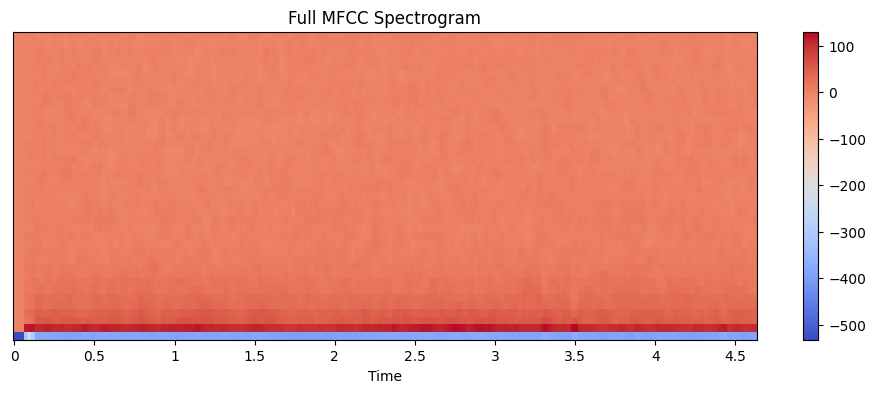

In [13]:
# Visualize MFCC Spectrogram
plt.figure(figsize=(12,4))

librosa.display.specshow(
    sample_mfcc,
    x_axis='time'
)

plt.colorbar()
plt.title("Full MFCC Spectrogram")
plt.show()

In [14]:
# Generate MFCC Dataset
X = []
y = []

for file, label in tqdm(
    zip(filtered_audio_files, filtered_labels),
    total=len(filtered_audio_files)
):

    mfcc = extract_full_mfcc(file)

    if mfcc is not None:

        X.append(mfcc)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

100%|██████████| 904/904 [07:31<00:00,  2.00it/s]

(904, 40, 200)
(904,)


In [15]:
# Add CNN Channel Dimension
X = X[..., np.newaxis]

print(X.shape)

(904, 40, 200, 1)


In [16]:
np.save(
    "/content/drive/MyDrive/AICA_Health_Project/X_mfcc_spectrogram.npy",
    X
)

np.save(
    "/content/drive/MyDrive/AICA_Health_Project/y_labels.npy",
    y
)

print("MFCC Spectrogram Dataset Saved")

MFCC Spectrogram Dataset Saved


In [20]:
X[0]

array([[[-5.32249634e+02],
        [-5.32249634e+02],
        [-5.32249634e+02],
        ...,
        [-3.90871918e+02],
        [-3.87223297e+02],
        [-3.88379730e+02]],

       [[ 0.00000000e+00],
        [ 0.00000000e+00],
        [ 0.00000000e+00],
        ...,
        [ 1.00877335e+02],
        [ 1.04146957e+02],
        [ 1.02843597e+02]],

       [[ 0.00000000e+00],
        [ 0.00000000e+00],
        [ 0.00000000e+00],
        ...,
        [ 4.71993408e+01],
        [ 4.52216568e+01],
        [ 4.36501770e+01]],

       ...,

       [[ 0.00000000e+00],
        [ 0.00000000e+00],
        [ 0.00000000e+00],
        ...,
        [-2.78862834e-01],
        [-1.31851101e+00],
        [ 7.95266867e-01]],

       [[ 0.00000000e+00],
        [ 0.00000000e+00],
        [ 0.00000000e+00],
        ...,
        [-2.33178949e+00],
        [-1.37699187e+00],
        [ 1.91004443e+00]],

       [[ 0.00000000e+00],
        [ 0.00000000e+00],
        [ 0.00000000e+00],
        ...,
        

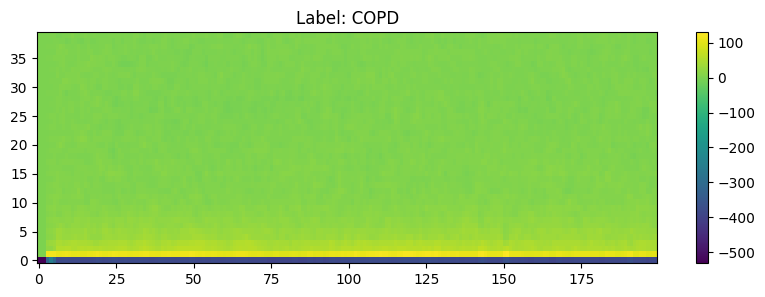

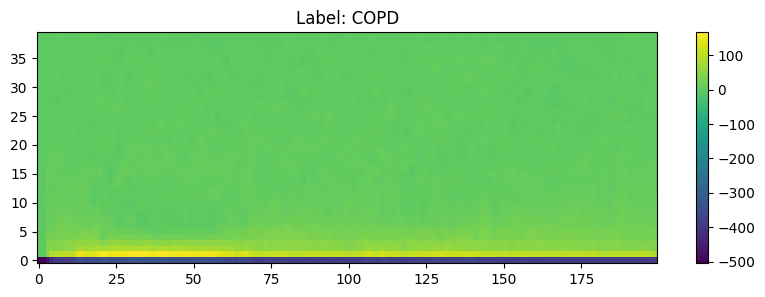

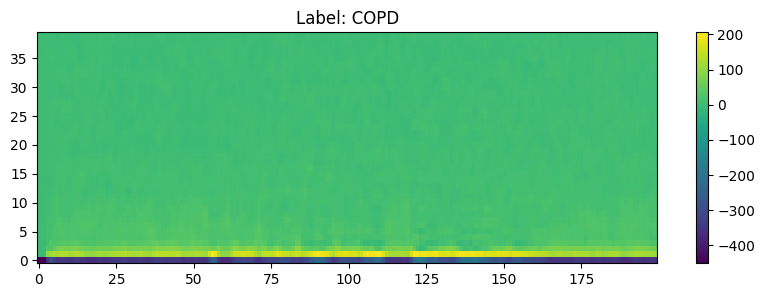

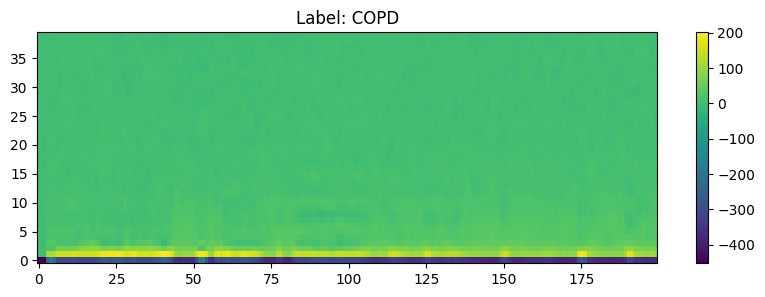

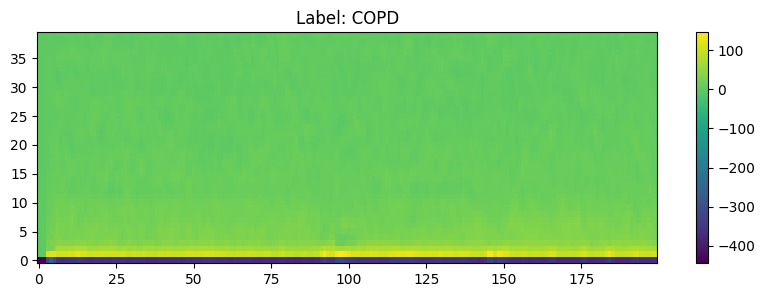

In [19]:
for i in range(5):
    plt.figure(figsize=(10,3))
    plt.imshow(X[i], aspect='auto', origin='lower')
    plt.title(f"Label: {y[i]}")
    plt.colorbar()
    plt.show()